# Synthetic Systems Engineering Graph — GNN Outlier Detection

This notebook generates a synthetic **Systems Engineering (SE) knowledge graph**, injects two types of structural outliers, converts the graph to PyTorch Geometric (PyG) format, and trains a **Graph Attention Network (GATv2)** to detect those outliers at the edge level.

**Graph schema**
- **Nodes**: Requirements (REQ), Functions (FUNC), Components (COMP), each arranged in a hierarchy by level
- **Edges**:
  - `hierarchy` — parent/child relationships within a domain
  - `allocated_to` — a requirement is assigned to a function or component
  - `satisfies` — a function/component fulfills a requirement

**Outlier types**
- **Type 1 (Missing Satisfaction)**: A requirement is allocated to a node, but no child of that node satisfies it
- **Type 2 (Illegal Satisfaction)**: A node satisfies a requirement that was never allocated to any of its parents

## 0. Imports

In [1]:
import sys
!{sys.executable} -m pip install torch_geometric

import random
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, GATConv, GCNConv, SAGEConv, RGCNConv
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## 1. Synthetic data generation

The following code generates a systems engineering graph with requirements, functions and components as well as two types of relationships: allocate and satisfy. There are three different graph models and outlier types of increasing complexity that we will be evaluating.

Simple: Any requirement that is allocated to an element, must be satisfied by that same element. If not, that allocate link is considered an outlier. Also a satisfy link can only point to a requirement that is allocated to it. If not, that satisfy link is considered an outlier.

Standard: Any requiremernt that is allocated to an element (function or component), must be satisfied by that element or one of its children in the hierarchy. If not, that allocate link is considered an outlier. Also  a satisfy link can only point to a requirement that is allocated to it or one of its parents. If not, that satisfy link is considered an outlier.

Complex:  If a requirement is allocated to an element (function or component), then that requirement must be decomposed and each of its children must be satisfied either directly or recursively through that same decomposition rule. A requirement whose children are not all satisfied is an outlier. Also, if a satisfy link points to a requirement that is not allocated to it or one of its parents or if that requirement is already satisfied through its children, that satisfy link is an outlier

`generate_random_tree` builds a directed tree of a given node type with a forced path to `target_depth`, then expands randomly until `target_size` is reached.

`generate_se_dataset_with_outliers` composes three domain trees into one graph, adds random `allocated_to` edges from every requirement to one function and one component, infers `satisfies` edges from children to parent-allocated requirements, and probabilistically injects outliers.

**Key parameters**
| Parameter | Default | Effect |
|---|---|---|
| `p_missing_satisfy` | 0.1 | Probability a required `satisfies` link is omitted → Type 1 outlier |
| `p_illegal_satisfy` | 0.05 | Probability a node satisfies an unrelated requirement → Type 2 outlier |

> **Reproducibility note**: No global random seed is set. Add `random.seed(42)`, `np.random.seed(42)`, and `torch.manual_seed(42)` at the top for consistent results across runs.

In [2]:

def generate_random_tree(prefix, node_type, target_size, target_depth):
    G = nx.DiGraph()
    root_id = f"{prefix}_0"
    G.add_node(root_id, type=node_type, level=0)
    all_nodes = [root_id]

    # Force a path to target_depth
    current_node = root_id
    for d in range(1, target_depth + 1):
        new_id = f"{prefix}_{len(all_nodes)}"
        G.add_node(new_id, type=node_type, level=d)
        G.add_edge(new_id, current_node, relation='hierarchy')
        all_nodes.append(new_id)
        current_node = new_id

    # Expand randomly
    while len(all_nodes) < target_size:
        parent = random.choice(all_nodes)
        if G.nodes[parent]['level'] < target_depth:
            new_id = f"{prefix}_{len(all_nodes)}"
            new_level = G.nodes[parent]['level'] + 1
            G.add_node(new_id, type=node_type, level=new_level)
            G.add_edge(new_id, parent, relation='hierarchy')
            all_nodes.append(new_id)
    return G, all_nodes

In [3]:
def generate_se_dataset_with_outliers_simple(
    req_size=100, req_depth=3,
    func_size=150, func_depth=4,
    comp_size=150, comp_depth=4,
    p_illegal_satisfy=0.05,
    p_missing_satisfy=0.1
):
    # 1. Generate Domain Trees
    req_tree, req_nodes = generate_random_tree("REQ", "requirement", req_size, req_depth)
    func_tree, func_nodes = generate_random_tree("FUNC", "function", func_size, func_depth)
    log_tree, log_nodes = generate_random_tree("COMP", "component", comp_size, comp_depth)
    G = nx.compose_all([req_tree, func_tree, log_tree])

    # 2. Add Random Allocations
    allocations = {node: [] for node in func_nodes + log_nodes}
    for req in req_nodes:
        target_f = random.choice(func_nodes)
        target_c = random.choice(log_nodes)
        
        G.add_edge(req, target_f, relation='allocated_to', outlier=False)
        G.add_edge(req, target_c, relation='allocated_to', outlier=False)
        
        allocations[target_f].append(req)
        allocations[target_c].append(req)

    # 3. Apply Simple Satisfaction & Outlier Logic (No Hierarchy Checked)
    for node in func_nodes + log_nodes:
        
        # Rule 1 Check: Allocated to this element -> Must be satisfied by this EXACT element
        for req in allocations[node]:
            if random.random() < p_missing_satisfy:
                # Outlier: Allocated but missing the exact satisfaction link
                G[req][node]['outlier'] = True
            else:
                # Valid: Direct 1-to-1 match
                G.add_edge(node, req, relation='satisfies', outlier=False)

        # Rule 2 Check: Inject Illegal Satisfy links
        # Satisfies a requirement NOT directly allocated to this exact node
        if random.random() < p_illegal_satisfy:
            valid_reqs = set(allocations[node])
            illegal_pool = list(set(req_nodes) - valid_reqs)
            
            if illegal_pool:
                wrong_req = random.choice(illegal_pool)
                G.add_edge(node, wrong_req, relation='satisfies', outlier=True)

    return G

In [4]:
def generate_se_dataset_with_outliers_standard(
    req_size=100, req_depth=3,
    func_size=150, func_depth=4,
    comp_size=150, comp_depth=4,
    p_illegal_satisfy=0.05,
    p_missing_satisfy=0.1
):
    # 1. Generate Domain Trees
    req_tree, req_nodes = generate_random_tree("REQ", "requirement", req_size, req_depth)
    func_tree, func_nodes = generate_random_tree("FUNC", "function", func_size, func_depth)
    log_tree, log_nodes = generate_random_tree("COMP", "component", comp_size, comp_depth)
    
    # Merge graphs
    G = nx.compose_all([req_tree, func_tree, log_tree])

    # Helper maps for clean ancestral lookups inside specific subgraphs
    # networkx.descendants find children because edges point from child to parent
    def get_all_descendants(graph, node):
        return nx.descendants(graph, node)
        
    def get_all_ancestors(graph, node):
        return nx.ancestors(graph, node)

    # 2. Add Random Allocations
    allocations = {node: [] for node in func_nodes + log_nodes}
    for req in req_nodes:
        target_f = random.choice(func_nodes)
        target_c = random.choice(log_nodes)
        
        G.add_edge(req, target_f, relation='allocated_to', outlier=False)
        G.add_edge(req, target_c, relation='allocated_to', outlier=False)
        
        allocations[target_f].append(req)
        allocations[target_c].append(req)

    # 3. Apply Satisfaction & Outlier Logic
    for node in func_nodes + log_nodes:
        # Get full hierarchy context using networkx
        # Node attributes include themselves, ancestors (parents up), and descendants (children down)
        node_ancestors = get_all_ancestors(G, node)
        node_descendants = get_all_descendants(G, node)
        
        # Rule 1 Check: Allocated to this element -> Must be satisfied by self or children
        for req in allocations[node]:
            # Simulate a missing satisfaction link (Creates an Outlier Allocation)
            if random.random() < p_missing_satisfy:
                G[req][node]['outlier'] = True
            else:
                # Valid path: satisfy from self or a random descendant child
                satisfier = random.choice([node] + list(node_descendants))
                G.add_edge(satisfier, req, relation='satisfies', outlier=False)

        # Rule 2 Check: Inject Illegal Satisfy links
        # Satisfies a requirement NOT allocated to self or any parent ancestors
        if random.random() < p_illegal_satisfy:
            # Gather all valid requirements for this node's line of ancestry
            valid_reqs = set(allocations[node])
            
            # FIX: Only look up ancestors that belong to the same engineering domain
            for ancestor in node_ancestors:
                if ancestor in allocations:  # Guarantees ancestor is a FUNC or COMP node
                    valid_reqs.update(allocations[ancestor])
                
            # Create pool of completely illegal requirements
            illegal_pool = list(set(req_nodes) - valid_reqs)
            if illegal_pool:
                wrong_req = random.choice(illegal_pool)
                G.add_edge(node, wrong_req, relation='satisfies', outlier=True)

    return G

In [5]:
def generate_se_dataset_with_outliers_complex(
    req_size=100, req_depth=3,
    func_size=150, func_depth=4,
    comp_size=150, comp_depth=4,
    p_illegal_satisfy=0.05,
    p_missing_satisfy=0.1
):
    # 1. Generate Domain Trees (Mock setup matching your structure)
    req_tree, req_nodes = generate_random_tree("REQ", "requirement", req_size, req_depth)
    func_tree, func_nodes = generate_random_tree("FUNC", "function", func_size, func_depth)
    log_tree, log_nodes = generate_random_tree("COMP", "component", comp_size, comp_depth)
    G = nx.compose_all([req_tree, func_tree, log_tree])

    # --- OPTIMIZATION STEP 1: PRE-COMPUTE AND CACHE STATIC HIERARCHIES ---
    # Store ancestors and descendants as standard Python sets for O(1) lookups
    node_descendants_cache = {n: nx.descendants(G, n) for n in G.nodes}
    node_ancestors_cache = {n: nx.ancestors(G, n) for n in G.nodes}
    
    # Pre-compute type lookups to avoid slow G.nodes[n]['type'] lookups in loops
    node_types = {n: G.nodes[n]['type'] for n in G.nodes}
    
    # Pre-compute immediate children for all nodes
    immediate_children_cache = {}
    for n in G.nodes:
        n_type = node_types[n]
        immediate_children_cache[n] = [
            pred for pred in G.predecessors(n) if node_types[pred] == n_type
        ]

    # Pre-identify leaf vs parent requirements
    req_nodes_set = set(req_nodes)
    parent_reqs_set = {r for r in req_nodes if len(immediate_children_cache[r]) > 0}

    # Pre-compute requirement parent pointers (each child node has max 1 tree parent)
    req_parents_map = {}
    for r in req_nodes:
        parents = [p for p in G.successors(r) if node_types[p] == 'requirement']
        if parents:
            req_parents_map[r] = parents[0]

    # 2. Add Random Allocations
    allocations = {node: [] for node in func_nodes + log_nodes}
    for req in req_nodes:
        target_f = random.choice(func_nodes)
        target_c = random.choice(log_nodes)
        G.add_edge(req, target_f, relation='allocated_to', outlier=False)
        G.add_edge(req, target_c, relation='allocated_to', outlier=False)
        allocations[target_f].append(req)
        allocations[target_c].append(req)

    satisfied_reqs = set()

    # 3. Apply Complex Satisfaction & Outlier Logic
    for node in func_nodes + log_nodes:
        # Pull cached traversal sets
        node_descendants = node_descendants_cache[node]
        node_ancestors = node_ancestors_cache[node]

        # Rule 1 Check: Children of allocated requirement must be satisfied
        for req in allocations[node]:
            req_children = immediate_children_cache[req]
            
            if not req_children:
                # Leaf requirement: Satisfy it directly or via sub-element
                if random.random() > p_missing_satisfy:
                    satisfier = random.choice([node] + list(node_descendants))
                    G.add_edge(satisfier, req, relation='satisfies', outlier=False)
                    satisfied_reqs.add(req)
                    
                    # Propagate satisfaction upward using optimized map lookups
                    curr_req = req
                    while curr_req in req_parents_map:
                        parent_req = req_parents_map[curr_req]
                        p_children = immediate_children_cache[parent_req]
                        
                        # Use O(1) set membership evaluation
                        if all(c in satisfied_reqs for c in p_children):
                            satisfied_reqs.add(parent_req)
                            curr_req = parent_req
                        else:
                            break
                else:
                    G[req][node]['outlier'] = True
            else:
                # Non-leaf requirement: Simulate decomposition satisfaction check
                missing_child_outlier = random.random() < p_missing_satisfy
                drop_child = random.choice(req_children) if missing_child_outlier else None
                
                for child in req_children:
                    if child == drop_child:
                        G[req][node]['outlier'] = True
                        continue 
                    
                    satisfier = random.choice([node] + list(node_descendants))
                    G.add_edge(satisfier, child, relation='satisfies', outlier=False)
                    satisfied_reqs.add(child)
                
                if all(c in satisfied_reqs for c in req_children):
                    satisfied_reqs.add(req)

        # Rule 2 Check: Illegal Satisfy Links
        if random.random() < p_illegal_satisfy:
            # --- OPTIMIZATION STEP 2: VECTORIZED SET OPERATIONS ---
            # Gather all valid allocations using cached ancestor indices
            valid_allocated_nodes = {node} | {a for a in node_ancestors if a in allocations}
            valid_reqs = set()
            for n in valid_allocated_nodes:
                valid_reqs.update(allocations[n])

            # Condition A: Completely unallocated requirements (Set subtraction)
            condition_a_reqs = req_nodes_set - valid_reqs
            
            # Condition B: Already satisfied parent requirements (Set intersection)
            condition_b_reqs = satisfied_reqs & parent_reqs_set

            # Merge illegal groups instantly without inner looping
            illegal_pool = list(condition_a_reqs | condition_b_reqs)

            if illegal_pool:
                wrong_req = random.choice(illegal_pool)
                G.add_edge(node, wrong_req, relation='satisfies', outlier=True)

    return G

## 2. Graph visualization

Two complementary views are provided.

`plot_se_system_v2` uses a spring-force layout. Good for seeing global connectivity and making outlier edges visually prominent.

`plot_se_clustered_by_domain_and_tier` places the three domains in separate columns with hierarchy level on the y-axis. Better for understanding the structured SE decomposition.

**Edge color key**
| Color | Edge type |
|---|---|
| Gray (faint) | Hierarchy — always valid |
| Red (faint) | Valid allocation |
| Orange (bold) | Type 1 outlier: unsatisfied allocation |
| Green (faint) | Valid satisfaction |
| Magenta (bold) | Type 2 outlier: illegal satisfaction |

In [6]:
def plot_se_system_v2(G):
    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    node_colors = [('#ADD8E6' if G.nodes[n]['type'] == 'requirement' else
                    '#90EE90' if G.nodes[n]['type'] == 'function' else '#FFD700') for n in G.nodes]

    # Edge filtering
    hier_edges = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'hierarchy']

    # Type 1: Orange allocations (missing satisfaction)
    alloc_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and not d.get('outlier')]
    alloc_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and d.get('outlier')]

    # Type 2: Magenta satisfaction (illegal link)
    sat_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and not d.get('outlier')]
    sat_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and d.get('outlier')]

    # Draw
    nx.draw_networkx_nodes(G, pos, node_size=80, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color='#CCCCCC', alpha=0.3, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_val, edge_color='red', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_out, edge_color='orange', width=2.5)
    nx.draw_networkx_edges(G, pos, edgelist=sat_val, edge_color='green', alpha=0.2)
    nx.draw_networkx_edges(G, pos, edgelist=sat_out, edge_color='magenta', width=2.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Req/Func/Comp', markerfacecolor='gray', markersize=10),
        Line2D([0], [0], color='orange', lw=2.5, label='Type 1: Unsatisfied Allocation'),
        Line2D([0], [0], color='magenta', lw=2.5, label='Type 2: Illegal Satisfaction'),
        Line2D([0], [0], color='red', lw=1, alpha=0.3, label='Valid Allocation'),
        Line2D([0], [0], color='green', lw=1, alpha=0.3, label='Valid Satisfaction')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title("Systems Engineering Data: Outlier Analysis")
    plt.axis('off')
    plt.show()

In [7]:
def plot_se_clustered_by_domain_and_tier(G):
    # Figure setup
    plt.figure(figsize=(9, 6))

    # 1. Define Cluster spacing
    domain_x = {'requirement': 0, 'function': 5, 'component': 10}
    pos = {}
    counts = {}

    for node, data in G.nodes(data=True):
        d_type = data['type']
        level = data['level']

        cluster_key = (d_type, level)
        counts[cluster_key] = counts.get(cluster_key, 0) + 1

        # Position = (Base Domain X + minor jitter, "-Level" Y)
        jitter = (counts[cluster_key] % 10) * 0.2
        pos[node] = (domain_x[d_type] + jitter, -level)

    # 2. Extract Edges
    hier_edges = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'hierarchy']
    alloc_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and not d.get('outlier')]
    alloc_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and d.get('outlier')]
    sat_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and not d.get('outlier')]
    sat_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and d.get('outlier')]

    # 3. Draw Elements
    node_colors = [('#ADD8E6' if G.nodes[n]['type'] == 'requirement' else
                    '#90EE90' if G.nodes[n]['type'] == 'function' else '#FFD700') for n in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_size=60, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color='gray', alpha=0.2, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_val, edge_color='red', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_out, edge_color='orange', width=2)
    nx.draw_networkx_edges(G, pos, edgelist=sat_val, edge_color='green', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=sat_out, edge_color='magenta', width=2)

    # Column labels positioned using axis fractions (0 to 1)
    # Added explicit fontsize=12
    plt.text(0.05, 1.05, "REQUIREMENTS", fontweight='bold', fontsize=12, ha='center', transform=plt.gca().transAxes)
    plt.text(0.50, 1.05, "FUNCTIONS", fontweight='bold', fontsize=12, ha='center', transform=plt.gca().transAxes)
    plt.text(0.95, 1.05, "COMPONENTS", fontweight='bold', fontsize=12, ha='center', transform=plt.gca().transAxes)

    # Main title positioned above column labels
    # Added explicit fontsize=14
    plt.suptitle("Clustered Systems Engineering Graph (Domain vs Tier)", fontweight='bold', fontsize=14, y=0.98)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Req/Func/Comp', markerfacecolor='gray', markersize=10),
        Line2D([0], [0], color='orange', lw=2.5, label='Type 1: Unsatisfied Allocation'),
        Line2D([0], [0], color='magenta', lw=2.5, label='Type 2: Illegal Satisfaction'),
        Line2D([0], [0], color='red', lw=1, alpha=0.3, label='Valid Allocation'),
        Line2D([0], [0], color='green', lw=1, alpha=0.3, label='Valid Satisfaction')
    ]
    plt.legend(handles=legend_elements, loc='lower left')
    plt.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 
    plt.show()


### Generate a sample graph

A smaller graph (50 nodes per domain, 150 total) is used here to keep runtime short. The default sizes in `generate_se_dataset_with_outliers` are 100/150/150 (400 total).

> **Known issue — train/test size mismatch**: `test_gnn_consolidated` (Section 7) calls the generator with default sizes, so the test graphs are ~2.7x larger than the training graph. Pass the same sizes to both, or train on the default sizes, for a fair comparison.

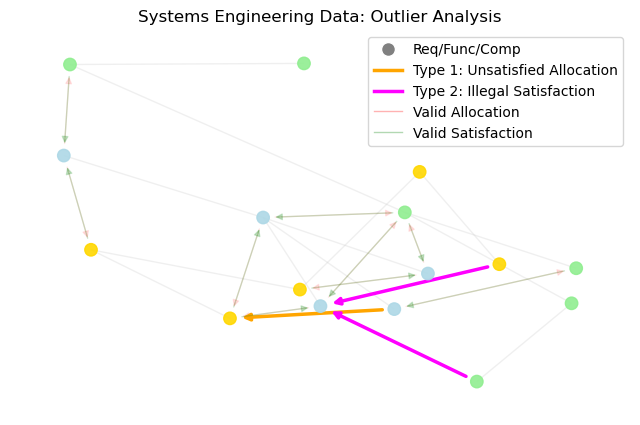

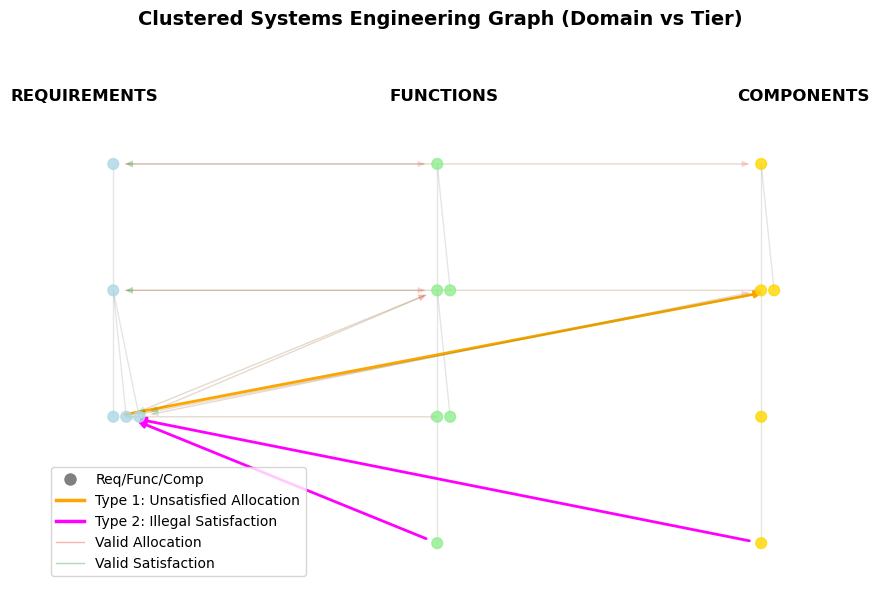

In [8]:
# Generate and Plot
g = generate_se_dataset_with_outliers_simple(req_size=5, req_depth=2,
    func_size=6, func_depth=3,
    comp_size=5, comp_depth=3,p_illegal_satisfy=0.2, p_missing_satisfy=0.2)
plot_se_system_v2(g)
plot_se_clustered_by_domain_and_tier(g)

In [9]:
def plot_se_aggregated_grid(G):
    AG = nx.MultiDiGraph()
    # NODE_SCALE calibrated for the 7.5" width
    NODE_SCALE = 150 
    legend_sizes = [1, 5, 10] 
    legend_widths = [1, 5]
    
    group_counts = {}
    for n, d in G.nodes(data=True):
        key = (d['type'], d['level'])
        group_counts[key] = group_counts.get(key, 0) + 1
    
    for key, count in group_counts.items():
        AG.add_node(key, size=count)

    for u, v, d in G.edges(data=True):
        u_key = (G.nodes[u]['type'], G.nodes[u]['level'])
        v_key = (G.nodes[v]['type'], G.nodes[v]['level'])
        rel = d['relation']
        is_outlier = d.get('outlier', False)
        
        if is_outlier:
            etype = 'outlier_t1' if rel == 'allocated_to' else 'outlier_t2'
        else:
            etype = 'valid' if rel != 'hierarchy' else 'hierarchy'

        found = False
        if v_key in AG[u_key]:
            for key in AG[u_key][v_key]:
                if AG[u_key][v_key][key]['etype'] == etype:
                    AG[u_key][v_key][key]['weight'] += 1
                    found = True
                    break
        if not found:
            AG.add_edge(u_key, v_key, etype=etype, weight=1)

    domain_order = {'requirement': 0, 'function': 1, 'component': 2}
    pos = {node: (domain_order[node[0]], -node[1]) for node in AG.nodes()}

    # Force 7.5x9 inch figure size
    fig, ax = plt.subplots(figsize=(7.5, 9)) 
    
    node_sizes = [AG.nodes[n]['size'] * NODE_SCALE for n in AG.nodes()]
    
    # FIXED: n[0] accesses the type in the (type, level) tuple
    node_colors = [('#ADD8E6' if n[0] == 'requirement' else 
                    '#90EE90' if n[0] == 'function' else '#FFD700') for n in AG.nodes()]
    
    nx.draw_networkx_nodes(AG, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black', ax=ax)

    for u, v, k, d in AG.edges(data=True, keys=True):
        weight = d['weight']
        etype = d['etype']
        rad = 0.1 + 0.15 * k
        s_margin, t_margin = 0, 0

        if etype == 'outlier_t1':
            color, alpha, width, a_size = 'red', 0.8, weight * 1.0, 12
            s_margin = np.sqrt(AG.nodes[u]['size'] * NODE_SCALE) / 2.0
            t_margin = np.sqrt(AG.nodes[v]['size'] * NODE_SCALE) / 2.0
        elif etype == 'outlier_t2':
            color, alpha, width, a_size = 'purple', 0.8, weight * 1.0, 12
            s_margin = np.sqrt(AG.nodes[u]['size'] * NODE_SCALE) / 2.0
            t_margin = np.sqrt(AG.nodes[v]['size'] * NODE_SCALE) / 2.0
        elif etype == 'valid':
            color, alpha, width, a_size = 'green', 0.15, weight * 1.0, 0.0001
        else:
            color, alpha, width, a_size = 'gray', 0.15, weight * 1.0, 0.0001

        nx.draw_networkx_edges(
            AG, pos, edgelist=[(u, v)], width=width, edge_color=color, alpha=alpha,
            connectionstyle=f"arc3,rad={rad}", ax=ax, arrows=True, arrowsize=a_size,
            min_source_margin=s_margin, min_target_margin=t_margin
        )

    # Labeling (Font 10+)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['REQUIREMENTS', 'FUNCTIONS', 'COMPONENTS'], fontsize=11, fontweight='bold')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel("Domains", fontsize=12, labelpad=15)
    
    levels = sorted(list(set(n[1] for n in AG.nodes())))
    ax.set_yticks([-l for l in levels])
    ax.set_yticklabels([f"Tier {l} (Roots)" if l == 0 else f"Tier {l}" for l in levels], fontsize=11, fontweight='bold')
    ax.set_ylabel("Hierarchical Tiers", fontsize=12, labelpad=15)

    for spine in ax.spines.values():
        spine.set_visible(False)

    def get_msize(count): return np.sqrt(count * NODE_SCALE)

    legend_elements = [
        Line2D([0], [0], color='none', label='--- DOMAIN TYPE ---'),
        Line2D([0], [0], marker='o', color='w', label='Requirement', markerfacecolor='#ADD8E6', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='Function', markerfacecolor='#90EE90', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='Component', markerfacecolor='#FFD700', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], color='none', label=''), 
        Line2D([0], [0], color='none', label='--- NODE POPULATION ---')
    ]

    for size in legend_sizes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', label=f'{size} Node(s)', 
                   markerfacecolor='gray', markersize=get_msize(size), markeredgecolor='black')
        )

    legend_elements += [
        Line2D([0], [0], color='none', label=''), 
        Line2D([0], [0], color='none', label='--- RELATIONSHIPS ---'),
        Line2D([0], [0], color='red', lw=4, label='Type 1 Outlier'),
        Line2D([0], [0], color='purple', lw=4, label='Type 2 Outlier'),
        Line2D([0], [0], color='green', lw=1.5, alpha=0.6, label='Valid Relation'),
        Line2D([0], [0], color='gray', lw=1.5, alpha=0.4, label='Hierarchy') # Added Hierarchy
    ]
    
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              title="Reference Legend", title_fontsize=12, fontsize=10, ncol=3, 
              labelspacing=1.2, handletextpad=1.5, borderpad=1.0)

    plt.grid(True, axis='both', linestyle='--', alpha=0.15)
    plt.subplots_adjust(top=0.90, bottom=0.22, left=0.15, right=0.90)
    plt.show()


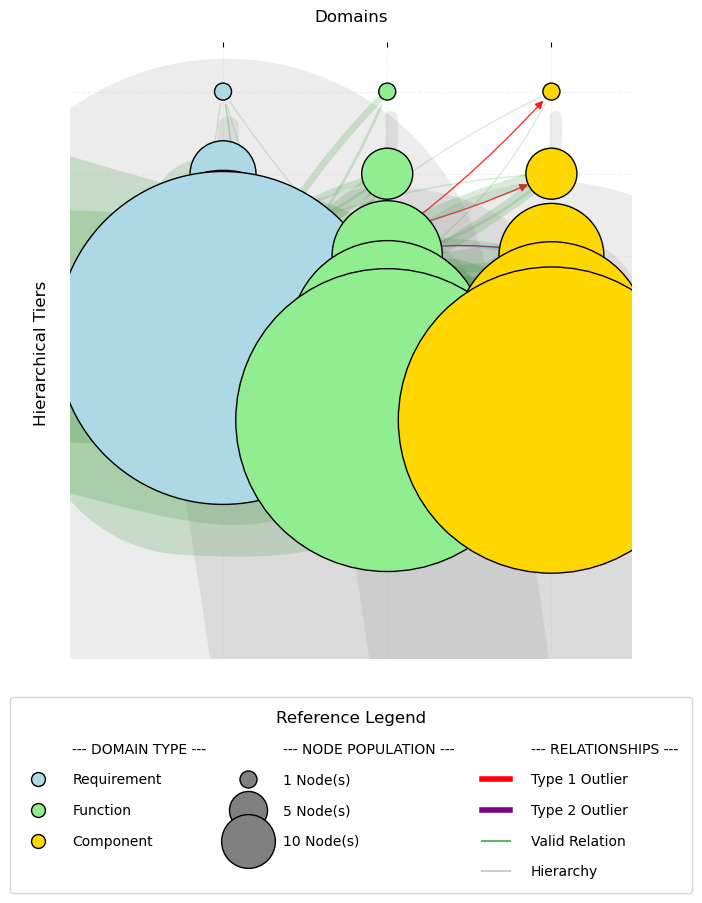

In [10]:
# ── Reproducibility ────────────────────────────────────────────
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Generate and Plot
g = generate_se_dataset_with_outliers_standard(req_size=500, req_depth=3,
    func_size=500, func_depth=4,
    comp_size=500, comp_depth=4,p_illegal_satisfy=0.05, p_missing_satisfy=0.1)
#plot_se_system_v2(g)
#plot_se_clustered_by_domain_and_tier(g)
plot_se_aggregated_grid(g)

## 3. Convert to PyTorch Geometric format

`convert_to_pyg_data` transforms the NetworkX graph into a `torch_geometric.data.Data` object.

**Tensor contents**
| Tensor | Shape | Description |
|---|---|---|
| `x` | `[N, 4]` | Node features: one-hot type `[is_req, is_func, is_comp]` + normalized level |
| `edge_index` | `[2, E]` | COO-format edge list (source row, target row) |
| `edge_attr` | `[E, 3]` | One-hot edge type `[is_hierarchy, is_allocated_to, is_satisfies]` |
| `y` | `[E]` | Binary edge label: 1 = outlier, 0 = valid |

> **Known issue — hierarchy edges in loss**: Hierarchy edges (`edge_attr[:, 0] == 1`) are always labeled 0, so they act as free correct predictions in both training and evaluation, inflating accuracy. Masking them out before computing loss and metrics would give a more honest picture of actual outlier detection performance.

In [11]:
def convert_to_pyg_data(G):
    # 1. Map string node IDs to integer indices
    nodes = list(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # 2. Encode Node Features (X)
    # We'll use One-Hot encoding for the 3 types: [Req, Func, Comp]
    type_map = {'requirement': 0, 'function': 1, 'component': 2}
    x_list = []
    for node in nodes:
        attr = G.nodes[node]
        # Feature vector: [Is_Req, Is_Func, Is_Comp, Normalized_Level]
        vec = [0.0, 0.0, 0.0, attr['level'] / 5.0]
        vec[type_map[attr['type']]] = 1.0
        x_list.append(vec)
    x = torch.tensor(x_list, dtype=torch.float)

    # 3. Encode Edges (edge_index) and Relationship Types
    edge_index_list = []
    edge_attr_list = []
    y_list = [] # Our target labels: 1 for outlier, 0 for valid

    rel_map = {'hierarchy': 0, 'allocated_to': 1, 'satisfies': 2}

    for u, v, data in G.edges(data=True):
        edge_index_list.append([node_to_idx[u], node_to_idx[v]])

        # Edge Feature: One-hot relationship type
        rel_vec = [0.0, 0.0, 0.0]
        rel_vec[rel_map[data['relation']]] = 1.0
        edge_attr_list.append(rel_vec)

        # Label: Is this an outlier?
        y_list.append(1 if data.get('outlier', False) else 0)

    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)
    y = torch.tensor(y_list, dtype=torch.float) # Or long if using CrossEntropy

    # 4. Create PyG Data object
    pyg_data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    return pyg_data, node_to_idx

# Convert our graph
pyg_dataset, mapping = convert_to_pyg_data(g)

print("PyG Data Summary:")
print(f"Number of nodes: {pyg_dataset.num_nodes}")
print(f"Number of edges: {pyg_dataset.num_edges}")
print(f"Feature size: {pyg_dataset.num_node_features}")
print(f"Outlier labels count: {int(pyg_dataset.y.sum())}")

PyG Data Summary:
Number of nodes: 1500
Number of edges: 3427
Feature size: 4
Outlier labels count: 113


### Train / Val / Test edge masks

Hierarchy edges are excluded from all supervised splits — they are always valid by construction
and would inflate every metric. They still participate in message passing.

Split: **60% train / 20% val / 20% test** over non-hierarchy edges only.

> **Discipline note**: evaluate on `edge_val_mask` during development. Run `edge_test_mask` once
> at the very end. Do not use test results to make tuning decisions — that re-introduces the same
> problem this split is meant to solve.

In [12]:
# ── Edge masks ─────────────────────────────────────────────────
# Exclude hierarchy edges from supervision (col 0 of edge_attr = is_hierarchy)
non_hier_idx = (pyg_dataset.edge_attr[:, 0] == 0).nonzero(as_tuple=True)[0]

n = len(non_hier_idx)
perm = torch.randperm(n)  # shuffle

train_end = int(0.6 * n)
val_end   = int(0.8 * n)

train_idx = non_hier_idx[perm[:train_end]]
val_idx   = non_hier_idx[perm[train_end:val_end]]
test_idx  = non_hier_idx[perm[val_end:]]

# Boolean masks over all edges
edge_train_mask = torch.zeros(pyg_dataset.num_edges, dtype=torch.bool)
edge_val_mask   = torch.zeros(pyg_dataset.num_edges, dtype=torch.bool)
edge_test_mask  = torch.zeros(pyg_dataset.num_edges, dtype=torch.bool)

edge_train_mask[train_idx] = True
edge_val_mask[val_idx]     = True
edge_test_mask[test_idx]   = True

pyg_dataset.edge_train_mask = edge_train_mask
pyg_dataset.edge_val_mask   = edge_val_mask
pyg_dataset.edge_test_mask  = edge_test_mask

print(f"Total supervised edges : {n}")
print(f"  Train : {edge_train_mask.sum().item()}")
print(f"  Val   : {edge_val_mask.sum().item()}")
print(f"  Test  : {edge_test_mask.sum().item()}")
print(f"  (Hierarchy edges excluded from all splits: "
      f"{(pyg_dataset.edge_attr[:, 0] == 1).sum().item()})")


Total supervised edges : 1931
  Train : 1158
  Val   : 386
  Test  : 387
  (Hierarchy edges excluded from all splits: 1496)


### Class imbalance weight

`pos_weight` is computed from **training edges only** (after masking) and shared across all
model training runs. It scales the loss contribution of outlier edges upward to compensate
for class imbalance.

> **Revision**: previously computed over all edges. Now restricted to `edge_train_mask` to
> avoid any information from val/test edges leaking into training.

In [13]:
# pos_weight computed on training edges only
train_labels = pyg_dataset.y[edge_train_mask]
pos_weight = (train_labels == 0).sum() / (train_labels == 1).sum()
print(f"pos_weight: {pos_weight:.2f}  "
      f"({int((train_labels==0).sum())} valid, "
      f"{int((train_labels==1).sum())} outlier in train split)")


pos_weight: 16.82  (1093 valid, 65 outlier in train split)


## 4. Model — SEOutlierDetector

A two-layer GNN encoder followed by an edge-level MLP classifier. The architecture is selected via the `gnn_type` parameter.

**Supported architectures**

| `gnn_type` | Uses edge features? | Key characteristic |
|---|---|---|
| `'GATv2'` | Yes (attention) | Dynamic attention — most expressive |
| `'GAT'` | Yes (attention) | Static attention |
| `'GCN'` | No | Degree-normalized averaging — simplest baseline |
| `'SAGE'` | No | Neighbor sampling and aggregation |
| `'RGCN'` | Yes (relation type) | Separate weights per relation type — designed for typed graphs |

**Why RGCN fits this problem well**: Your graph has exactly three relation types (`hierarchy`, `allocated_to`, `satisfies`). RGCN learns separate transformation matrices for each relation, allowing it to treat a `satisfies` edge very differently from a `hierarchy` edge — which is exactly the right inductive bias for detecting structural outliers in an SE knowledge graph.

**Forward pass** (all architectures)
```
x [N, 4]
  └─ GNN layer 1  →  activation  →  [N, hidden]
       └─ GNN layer 2             →  [N, hidden]
            └─ for each edge (u,v): cat(h_u, h_v)  →  [E, hidden*2]
                 └─ Linear → ReLU → Linear → logit  →  [E, 1]
```

> **Note on GCN and SAGE**: These architectures do not use `edge_attr` during message passing, so the edge type (relation) is invisible to them. They can only infer outlier status from the node embeddings alone. GAT, GATv2, and RGCN all incorporate edge type information and have a structural advantage on this problem.

In [14]:
class SEOutlierDetector(torch.nn.Module):
    def __init__(self, node_features, edge_features, hidden_channels, gnn_type='GATv2'):
        super().__init__()
        self.gnn_type = gnn_type

        if gnn_type == 'GATv2':
            self.conv1 = GATv2Conv(node_features, hidden_channels, heads=4, edge_dim=edge_features)
            self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, heads=1, edge_dim=edge_features)
        elif gnn_type == 'GAT':
            self.conv1 = GATConv(node_features, hidden_channels, heads=4, edge_dim=edge_features)
            self.conv2 = GATConv(hidden_channels * 4, hidden_channels, heads=1, edge_dim=edge_features)
        elif gnn_type == 'GCN':
            self.conv1 = GCNConv(node_features, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, hidden_channels)
        elif gnn_type == 'SAGE':
            self.conv1 = SAGEConv(node_features, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        elif gnn_type == 'RGCN':
            # num_relations=3: hierarchy / allocated_to / satisfies
            self.conv1 = RGCNConv(node_features, hidden_channels, num_relations=3)
            self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations=3)
        else:
            raise ValueError(f"Unknown gnn_type '{gnn_type}'. "
                             "Choose from: 'GATv2', 'GAT', 'GCN', 'SAGE', 'RGCN'.")

        self.edge_classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels * 2, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        if self.gnn_type in ('GATv2', 'GAT'):
            # Attention-based: edge_attr informs attention weights directly
            h = self.conv1(x, edge_index, edge_attr)
            h = F.elu(h)
            h = self.conv2(h, edge_index, edge_attr)

        elif self.gnn_type in ('GCN', 'SAGE'):
            # No edge feature support — edge_attr is not used in message passing
            h = self.conv1(x, edge_index)
            h = F.relu(h)
            h = self.conv2(h, edge_index)

        elif self.gnn_type == 'RGCN':
            # RGCN expects integer relation indices, not one-hot vectors
            # argmax converts [0,1,0] -> 1, [0,0,1] -> 2, etc.
            edge_type = edge_attr.argmax(dim=1)
            h = self.conv1(x, edge_index, edge_type)
            h = F.relu(h)
            h = self.conv2(h, edge_index, edge_type)

        row, col = edge_index
        edge_feat = torch.cat([h[row], h[col]], dim=-1)
        return self.edge_classifier(edge_feat).squeeze()

## 5. Model registry

All models are initialized from a single list. **To skip an architecture, comment out its line in `MODELS_TO_RUN`.**

All models share the same hyperparameters (`hidden_channels=32`) so the comparison is architecture-only.

In [15]:
# ── To skip a model, comment out its line ──────────────────────
MODELS_TO_RUN = [
    'GATv2',
    'GAT',
    'GCN',
    'SAGE',
    'RGCN',
]
# ────────────────────────────────────────────────────────────────

models = {
    name: SEOutlierDetector(
        node_features=pyg_dataset.num_node_features,
        edge_features=pyg_dataset.edge_attr.size(1),
        hidden_channels=32,
        gnn_type=name
    )
    for name in MODELS_TO_RUN
}

for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:8s} | {n_params:,} trainable parameters")

GATv2    | 12,449 trainable parameters
GAT      | 7,841 trainable parameters
GCN      | 3,329 trainable parameters
SAGE     | 4,481 trainable parameters
RGCN     | 6,785 trainable parameters


## 6. Training

A single `train()` function is shared across all architectures. Each model gets its own Adam optimizer and `BCEWithLogitsLoss` criterion (all using the same `pos_weight` computed earlier).

Training runs for `EPOCHS` epochs per model sequentially. Adjust `EPOCHS` or `LOG_EVERY` as needed.

> **Known issue — no validation split**: All training and evaluation uses the full `pyg_dataset` with no held-out edges. Metrics reflect training-graph performance. See Section 8 for generalization testing on unseen graphs.

In [16]:
def train(model, optimizer, criterion, data):
    """Single training step — shared by all architectures.
    Loss is computed on training edges only (edge_train_mask).
    All edges participate in message passing.
    """
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)
    # Mask: supervise on training edges only
    loss = criterion(out[data.edge_train_mask], data.y[data.edge_train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


EPOCHS   = 1001
LOG_EVERY = 100

# Build optimizers and loss functions for each active model
optimizers = {
    name: torch.optim.Adam(m.parameters(), lr=0.01)
    for name, m in models.items()
}
criterions = {
    name: torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for name in models
}

# Train all active models
for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  Training {name}")
    print(f"{'='*45}")
    for epoch in range(EPOCHS):
        loss = train(model, optimizers[name], criterions[name], pyg_dataset)
        if epoch % LOG_EVERY == 0:
            # Val loss — no gradient, no mask leak
            model.eval()
            with torch.no_grad():
                out = model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)
                val_loss = criterions[name](
                    out[pyg_dataset.edge_val_mask],
                    pyg_dataset.y[pyg_dataset.edge_val_mask]
                ).item()
            model.train()
            print(f"  Epoch {epoch:04d} | Train loss: {loss:.4f} | Val loss: {val_loss:.4f}")



  Training GATv2
  Epoch 0000 | Train loss: 1.3088 | Val loss: 1.3282
  Epoch 0100 | Train loss: 0.4806 | Val loss: 1.6329
  Epoch 0200 | Train loss: 0.2967 | Val loss: 3.6283
  Epoch 0300 | Train loss: 0.2991 | Val loss: 3.4738
  Epoch 0400 | Train loss: 0.1150 | Val loss: 5.7245
  Epoch 0500 | Train loss: 0.0799 | Val loss: 7.9896
  Epoch 0600 | Train loss: 0.4298 | Val loss: 2.2182
  Epoch 0700 | Train loss: 0.2489 | Val loss: 5.8579
  Epoch 0800 | Train loss: 0.3761 | Val loss: 3.9712
  Epoch 0900 | Train loss: 0.1525 | Val loss: 9.2115
  Epoch 1000 | Train loss: 0.1196 | Val loss: 12.2749

  Training GAT
  Epoch 0000 | Train loss: 1.3121 | Val loss: 1.3157
  Epoch 0100 | Train loss: 0.7242 | Val loss: 1.4070
  Epoch 0200 | Train loss: 0.5826 | Val loss: 2.6694
  Epoch 0300 | Train loss: 0.6440 | Val loss: 2.7349
  Epoch 0400 | Train loss: 0.3804 | Val loss: 3.1867
  Epoch 0500 | Train loss: 0.3751 | Val loss: 3.3222
  Epoch 0600 | Train loss: 0.3246 | Val loss: 4.1213
  Epoch 070

## 7. Evaluation

`evaluate_model` now accepts a `mask` and `split_name` argument, allowing the same function
to be used for val and test evaluation.

- **Val split**: use during development to tune hyperparameters and compare architectures.
- **Test split**: run once at the very end. Do not use test results to make tuning decisions.

> **Revision**: the old version evaluated on all edges (including hierarchy and training edges).
> This version applies the supplied mask before computing all metrics.

> **Note on the per-type bar chart**: raw accuracy is shown. F1-score per type would be more
> informative given class imbalance.

--- Overall Performance (GATv2) | val ---
              precision    recall  f1-score   support

       Valid       0.95      0.92      0.94       364
     Outlier       0.18      0.27      0.21        22

    accuracy                           0.89       386
   macro avg       0.57      0.60      0.58       386
weighted avg       0.91      0.89      0.90       386



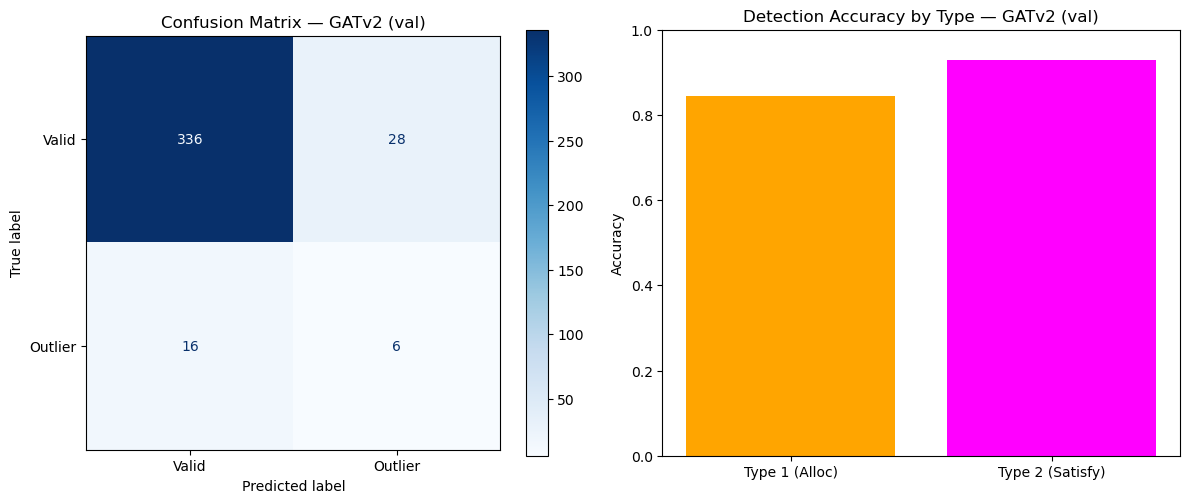

--- Overall Performance (GAT) | val ---
              precision    recall  f1-score   support

       Valid       0.97      0.87      0.92       364
     Outlier       0.19      0.50      0.28        22

    accuracy                           0.85       386
   macro avg       0.58      0.69      0.60       386
weighted avg       0.92      0.85      0.88       386



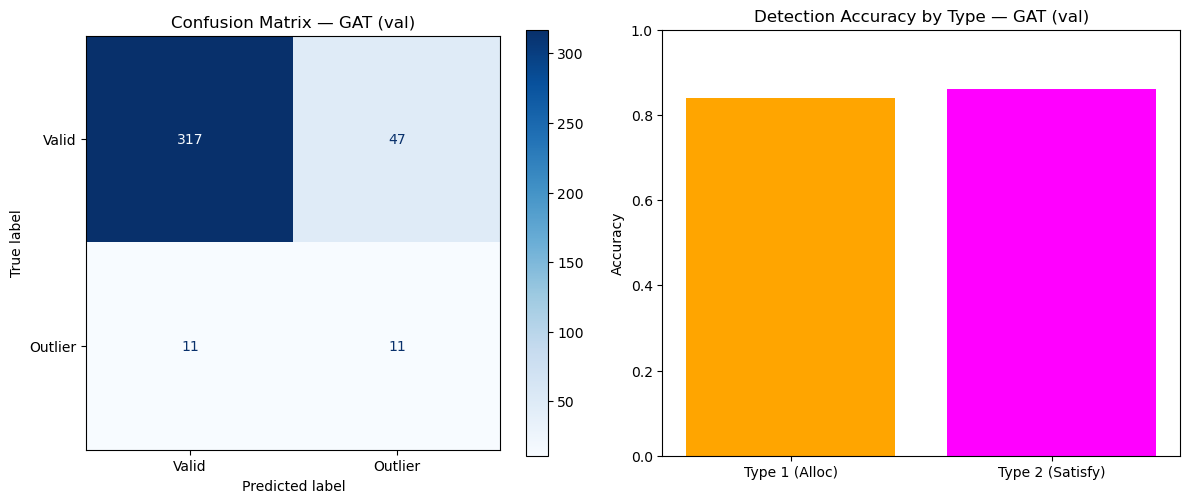

--- Overall Performance (GCN) | val ---
              precision    recall  f1-score   support

       Valid       0.97      0.93      0.95       364
     Outlier       0.27      0.45      0.34        22

    accuracy                           0.90       386
   macro avg       0.62      0.69      0.64       386
weighted avg       0.93      0.90      0.91       386



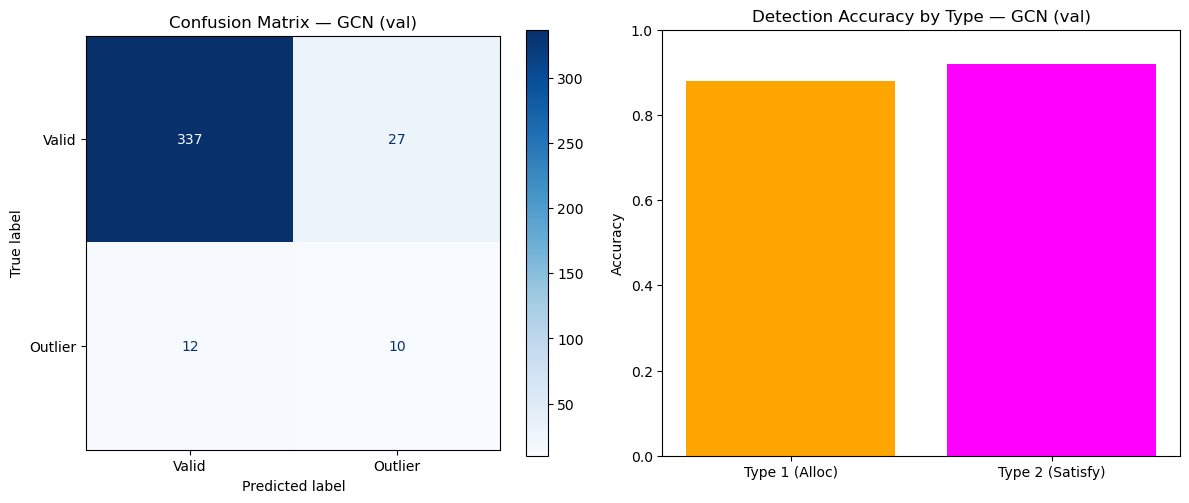

--- Overall Performance (SAGE) | val ---
              precision    recall  f1-score   support

       Valid       0.95      0.97      0.96       364
     Outlier       0.31      0.23      0.26        22

    accuracy                           0.93       386
   macro avg       0.63      0.60      0.61       386
weighted avg       0.92      0.93      0.92       386



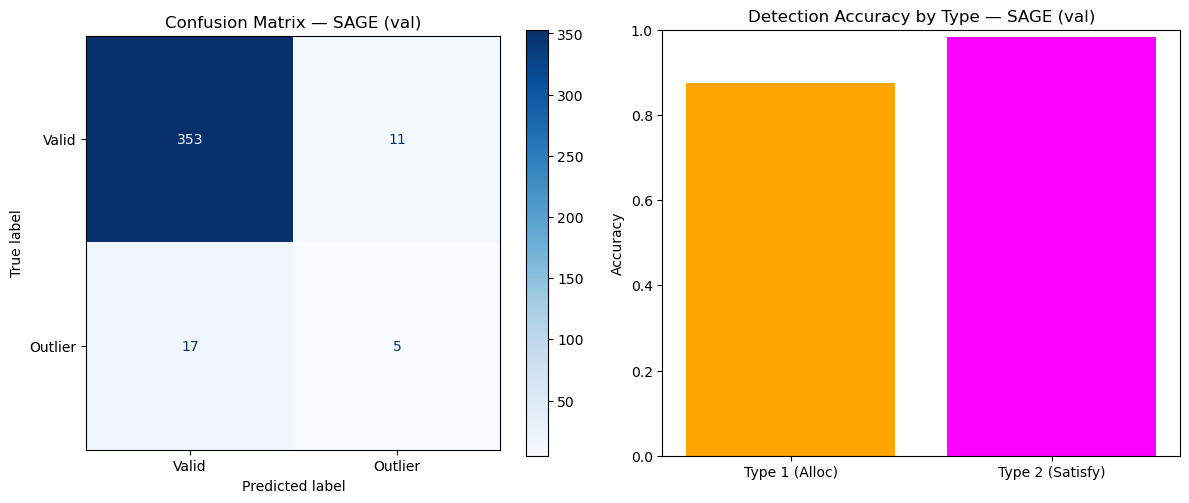

--- Overall Performance (RGCN) | val ---
              precision    recall  f1-score   support

       Valid       0.96      0.95      0.95       364
     Outlier       0.26      0.32      0.29        22

    accuracy                           0.91       386
   macro avg       0.61      0.63      0.62       386
weighted avg       0.92      0.91      0.91       386



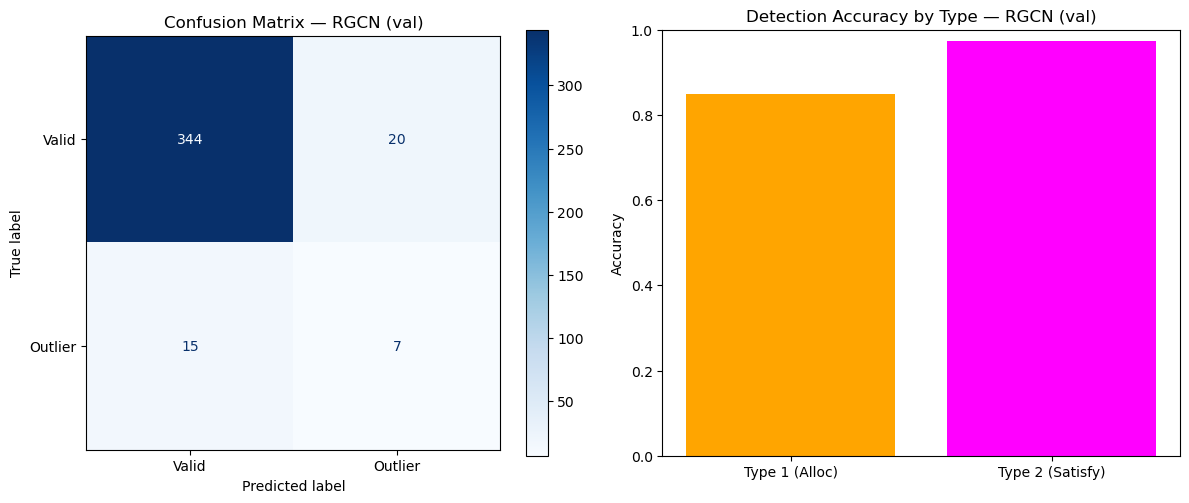

--- Overall Performance (GATv2) | test ---
              precision    recall  f1-score   support

       Valid       0.95      0.91      0.93       361
     Outlier       0.20      0.31      0.24        26

    accuracy                           0.87       387
   macro avg       0.57      0.61      0.59       387
weighted avg       0.90      0.87      0.88       387



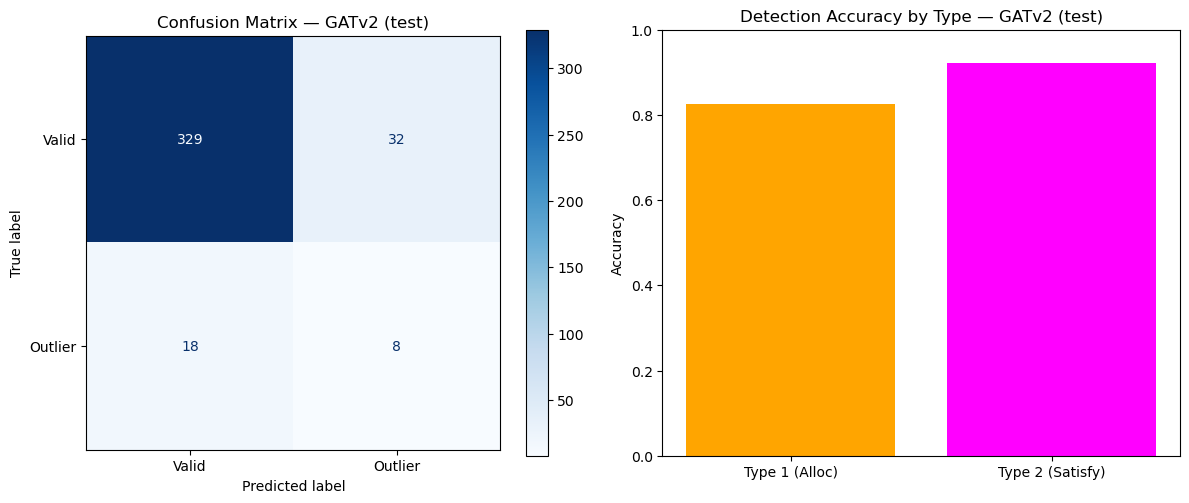

--- Overall Performance (GAT) | test ---
              precision    recall  f1-score   support

       Valid       0.95      0.88      0.91       361
     Outlier       0.17      0.35      0.23        26

    accuracy                           0.84       387
   macro avg       0.56      0.61      0.57       387
weighted avg       0.90      0.84      0.87       387



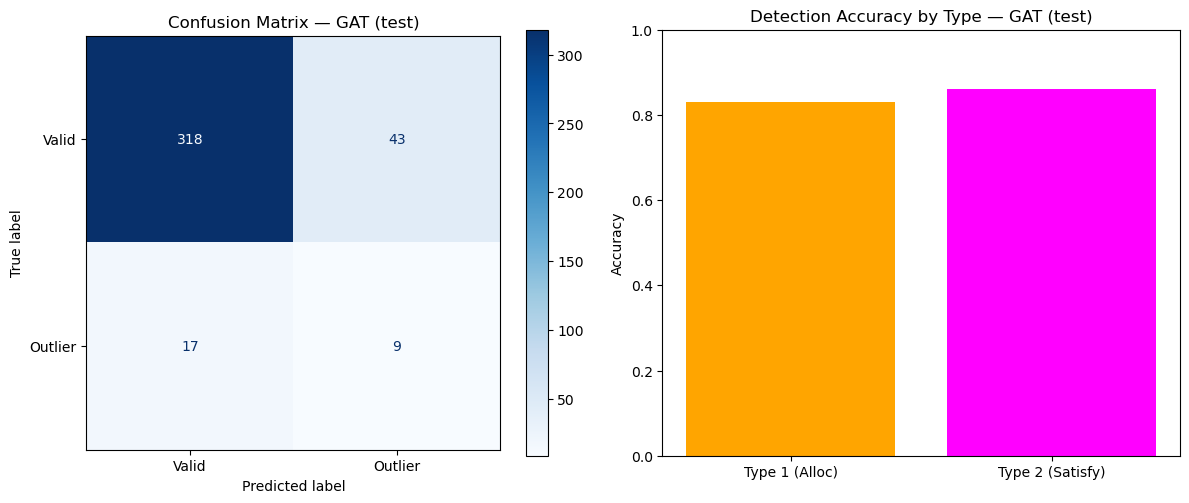

--- Overall Performance (GCN) | test ---
              precision    recall  f1-score   support

       Valid       0.95      0.92      0.94       361
     Outlier       0.22      0.31      0.26        26

    accuracy                           0.88       387
   macro avg       0.59      0.62      0.60       387
weighted avg       0.90      0.88      0.89       387



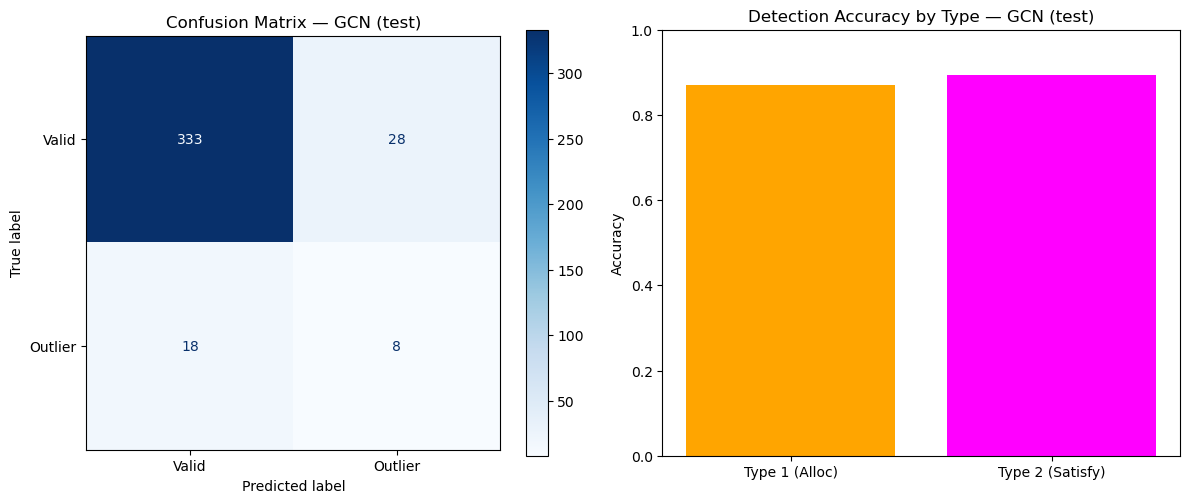

--- Overall Performance (SAGE) | test ---
              precision    recall  f1-score   support

       Valid       0.96      0.93      0.95       361
     Outlier       0.33      0.46      0.39        26

    accuracy                           0.90       387
   macro avg       0.65      0.70      0.67       387
weighted avg       0.92      0.90      0.91       387



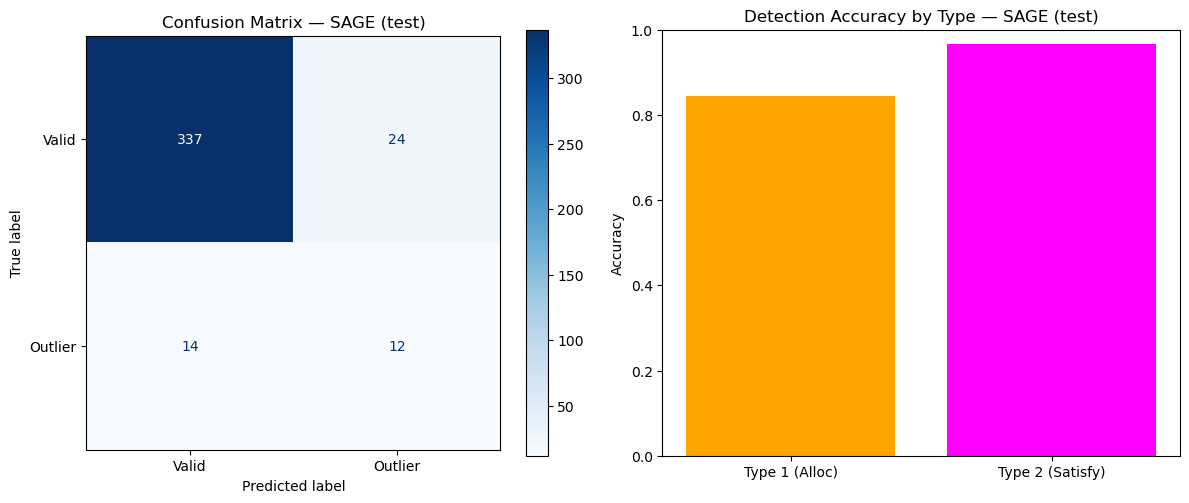

--- Overall Performance (RGCN) | test ---
              precision    recall  f1-score   support

       Valid       0.95      0.94      0.95       361
     Outlier       0.29      0.31      0.30        26

    accuracy                           0.90       387
   macro avg       0.62      0.63      0.62       387
weighted avg       0.91      0.90      0.90       387



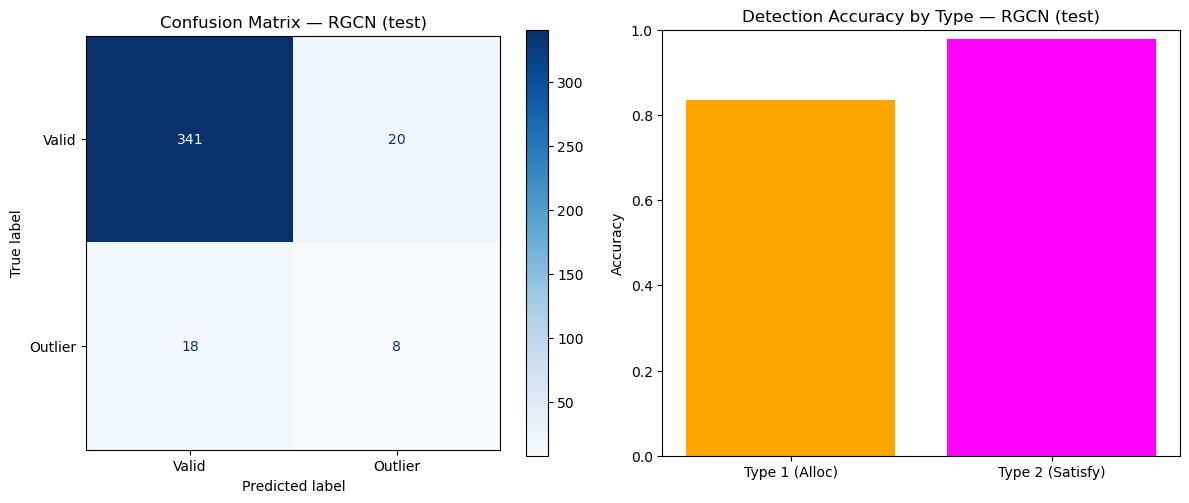

In [26]:
def evaluate_model(model, data, mask, split_name='val'):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index, data.edge_attr)
        probs  = torch.sigmoid(logits[mask])
        preds  = (probs > 0.5).float()

    y_true = data.y[mask].cpu().numpy()
    y_pred = preds.cpu().numpy()

    cm = confusion_matrix(y_true, y_pred)

    is_alloc   = (data.edge_attr[mask][:, 1] == 1).cpu().numpy()
    is_satisfy = (data.edge_attr[mask][:, 2] == 1).cpu().numpy()

    print(f"--- Overall Performance ({model.gnn_type}) | {split_name} ---")
    print(classification_report(y_true, y_pred, target_names=['Valid', 'Outlier']))

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay(cm, display_labels=['Valid', 'Outlier']).plot(ax=ax[0], cmap='Blues')
    ax[0].set_title(f"Confusion Matrix — {model.gnn_type} ({split_name})")

    type1_acc = (y_true[is_alloc]   == y_pred[is_alloc]).mean()   if any(is_alloc)   else 0
    type2_acc = (y_true[is_satisfy] == y_pred[is_satisfy]).mean() if any(is_satisfy) else 0

    ax[1].bar(['Type 1 (Alloc)', 'Type 2 (Satisfy)'], [type1_acc, type2_acc],
              color=['orange', 'magenta'])
    ax[1].set_ylim(0, 1)
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title(f"Detection Accuracy by Type — {model.gnn_type} ({split_name})")

    plt.tight_layout()
    plt.show()


# Evaluate all models on val split (use during development)
for name, model in models.items():
    evaluate_model(model, pyg_dataset, pyg_dataset.edge_val_mask, split_name='val')

# Evaluate all models on test split (run once at the end)
for name, model in models.items():
    evaluate_model(model, pyg_dataset, pyg_dataset.edge_test_mask, split_name='test')


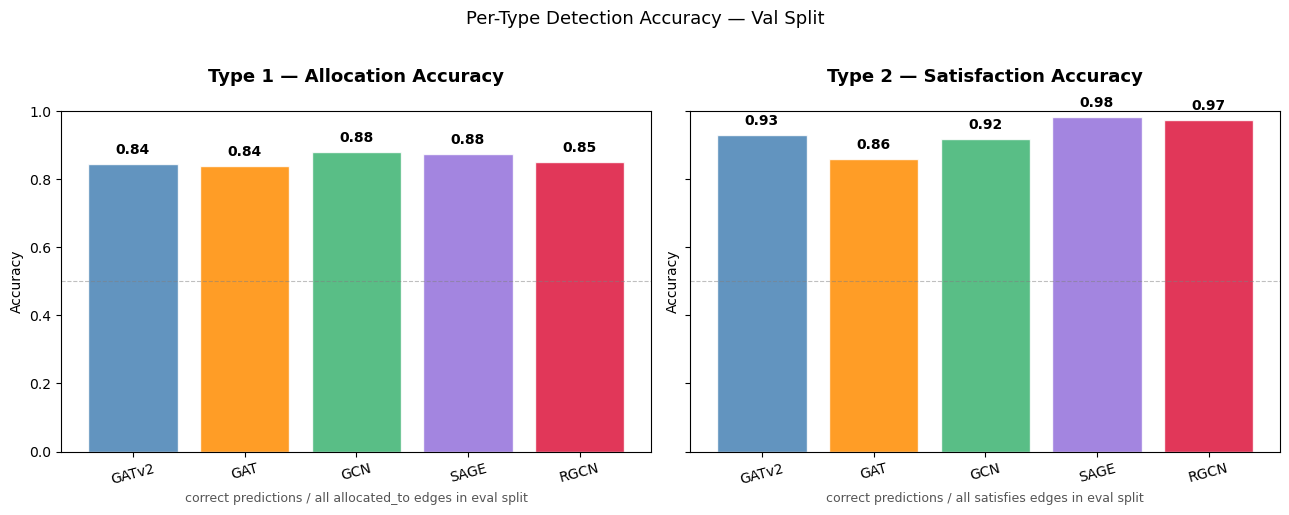

In [28]:
# ── Collect per-type accuracy for each model ──────────────────
# Using val split — switch to edge_test_mask for final evaluation
eval_mask = pyg_dataset.edge_val_mask

model_names = []
type1_accs  = []
type2_accs  = []

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        logits = model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)
        preds  = (torch.sigmoid(logits[eval_mask]) > 0.5).float().cpu().numpy()

    y_true     = pyg_dataset.y[eval_mask].cpu().numpy()
    is_alloc   = (pyg_dataset.edge_attr[eval_mask][:, 1] == 1).cpu().numpy()
    is_satisfy = (pyg_dataset.edge_attr[eval_mask][:, 2] == 1).cpu().numpy()

    type1 = (y_true[is_alloc]   == preds[is_alloc]).mean()   if any(is_alloc)   else 0
    type2 = (y_true[is_satisfy] == preds[is_satisfy]).mean() if any(is_satisfy) else 0

    model_names.append(name)
    type1_accs.append(type1)
    type2_accs.append(type2)

colors = [arch_colors[name] for name in model_names]

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

bar_configs = [
    (axes[0], type1_accs, 'Type 1 — Allocation Accuracy',
     'correct predictions / all allocated_to edges in eval split'),
    (axes[1], type2_accs, 'Type 2 — Satisfaction Accuracy',
     'correct predictions / all satisfies edges in eval split'),
]

for ax, values, title, subtitle in bar_configs:
    bars = ax.bar(model_names, values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 1)
    ax.set_title(f'{title}\n', fontsize=13, fontweight='bold')
    ax.set_xlabel(subtitle, fontsize=9, color='#555555')
    ax.set_ylabel('Accuracy')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Per-Type Detection Accuracy', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Precision, Recall, and F1 by Architecture

The per-type accuracy metric used above is misleading under class imbalance — a model that
labels every edge as valid scores ~95% accuracy while finding zero real violations. These
three metrics give a clearer picture of outlier detection performance.

All three are computed for the **outlier class only** (`pos_label=1`).

| Metric | Formula | Question it answers |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all edges the model flagged, what fraction were real outliers? |
| **Recall** | TP / (TP + FN) | Of all real outliers, what fraction did the model catch? |
| **F1** | 2 × (P × R) / (P + R) | Are both precision and recall good simultaneously? |

Precision and recall trade off against each other — a model can trivially maximize recall
by flagging everything, or trivially maximize precision by flagging almost nothing. F1 is
the harmonic mean of the two and penalizes hard if either is poor, making it the most
honest single-number summary for imbalanced classification.

The dashed line at 0.5 is a visual reference — a random classifier would score near 0.5
on each metric given balanced predictions, so anything below it warrants attention.

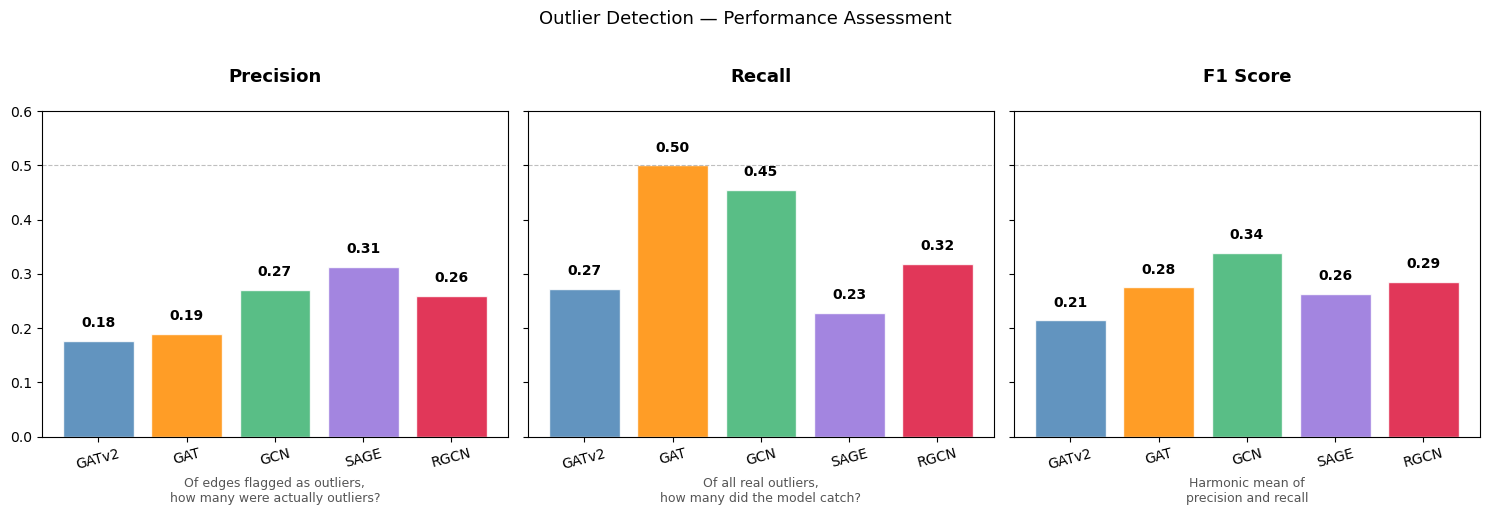

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Color per architecture ─────────────────────────────────────
# Defined once here so the same color appears across all three charts.
# Add or remove entries if you enable/disable architectures above.
arch_colors = {
    'GATv2': 'steelblue',
    'GAT':   'darkorange',
    'GCN':   'mediumseagreen',
    'SAGE':  'mediumpurple',
    'RGCN':  'crimson',
}

# ── Collect metrics for each model ────────────────────────────
# Switch to edge_test_mask for final evaluation — use val during development.
eval_mask = pyg_dataset.edge_val_mask

model_names = []
precisions  = []
recalls     = []
f1s         = []

for name, model in models.items():
    # Set model to eval mode — disables dropout and batch norm if present
    model.eval()
    with torch.no_grad():
        # Full forward pass on the entire graph — mask is applied afterward
        logits = model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)

        # Slice to eval edges only, apply sigmoid to convert logits → probabilities,
        # then threshold at 0.5 to get binary predictions (0=valid, 1=outlier)
        preds = (torch.sigmoid(logits[eval_mask]) > 0.5).float().cpu().numpy()

    # Ground truth labels for the eval edges only
    y_true = pyg_dataset.y[eval_mask].cpu().numpy()

    model_names.append(name)

    # pos_label=1 means all three metrics are computed for the outlier class only.
    # zero_division=0 handles the case where a model never predicts any outliers
    # (precision would be undefined — set to 0 rather than raising an error).
    precisions.append(precision_score(y_true, preds, pos_label=1, zero_division=0))
    recalls.append(   recall_score(   y_true, preds, pos_label=1, zero_division=0))
    f1s.append(       f1_score(       y_true, preds, pos_label=1, zero_division=0))

# Build color list in the same order as model_names so bars align correctly
colors = [arch_colors[name] for name in model_names]

# ── Plot ───────────────────────────────────────────────────────
# sharey=True keeps all three charts on the same 0-1 axis for visual comparability
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Each tuple: (axis, values, title, subtitle explaining what the metric means)
bar_configs = [
    (axes[0], precisions, 'Precision',  'Of edges flagged as outliers,\nhow many were actually outliers?'),
    (axes[1], recalls,    'Recall',     'Of all real outliers,\nhow many did the model catch?'),
    (axes[2], f1s,        'F1 Score',   'Harmonic mean of\nprecision and recall'),
]

for ax, values, title, subtitle in bar_configs:
    bars = ax.bar(model_names, values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 0.6)
    ax.set_title(f'{title}\n', fontsize=13, fontweight='bold')

    # Subtitle doubles as an x-axis label — reminds the reader what the metric means
    ax.set_xlabel(subtitle, fontsize=9, color='#555555')

    # Dashed reference line at 0.5 — anything below is worse than a coin flip
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='x', rotation=15)

    # Annotate each bar with its numeric value
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Outlier Detection — Performance Assessment',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

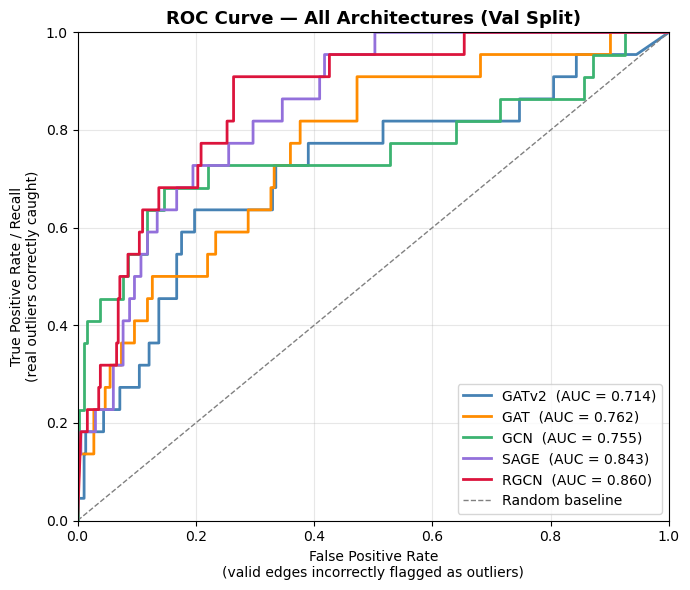

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# ── Collect predicted probabilities for each model ────────────
# ROC curve needs raw probabilities, not thresholded predictions.
# Switch to edge_test_mask for final evaluation.
eval_mask = pyg_dataset.edge_val_mask
y_true    = pyg_dataset.y[eval_mask].cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        logits = model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)
        # Keep as probabilities — do NOT threshold here
        probs  = torch.sigmoid(logits[eval_mask]).cpu().numpy()

    fpr, tpr, thresholds = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)

    ax.plot(fpr, tpr, color=arch_colors[name], linewidth=2,
            label=f'{name}  (AUC = {auc:.3f})')

# Diagonal = random classifier baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random baseline')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('False Positive Rate\n(valid edges incorrectly flagged as outliers)',
              fontsize=10)
ax.set_ylabel('True Positive Rate / Recall\n(real outliers correctly caught)',
              fontsize=10)
ax.set_title('ROC Curve — All Architectures (Val Split)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Generalization test on unseen graphs

`test_gnn_consolidated` generates fresh graphs the model has never seen and pools results across all of them. This is the primary performance measure.

Test graphs use the same size as training (`req_size=50, func_size=50, comp_size=50`) to avoid an unintentional distribution shift.

Each model produces a consolidated confusion matrix. After all models are tested, a single combined bar chart compares Type 1 and Type 2 accuracy across all architectures.

Run across all active models by iterating `models.items()`.


--- Generalization Test: GATv2 ---


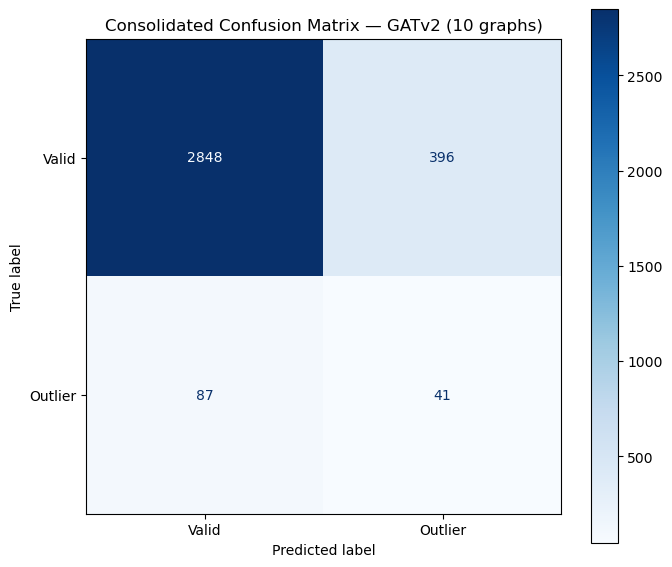


--- Generalization Test: GAT ---


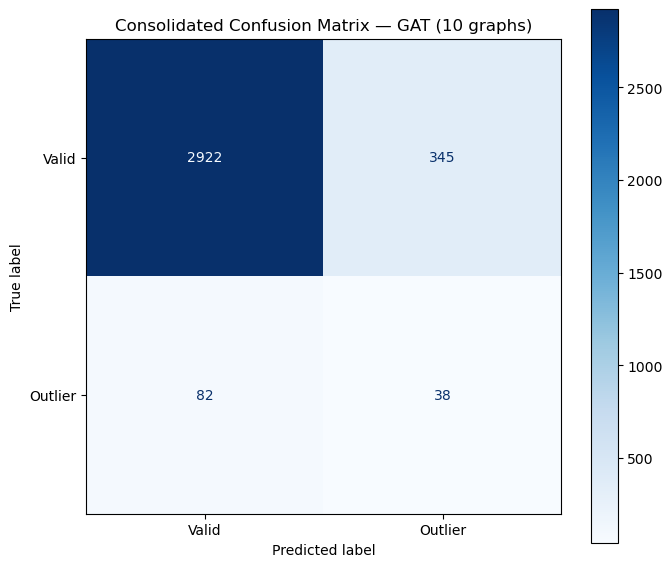


--- Generalization Test: GCN ---


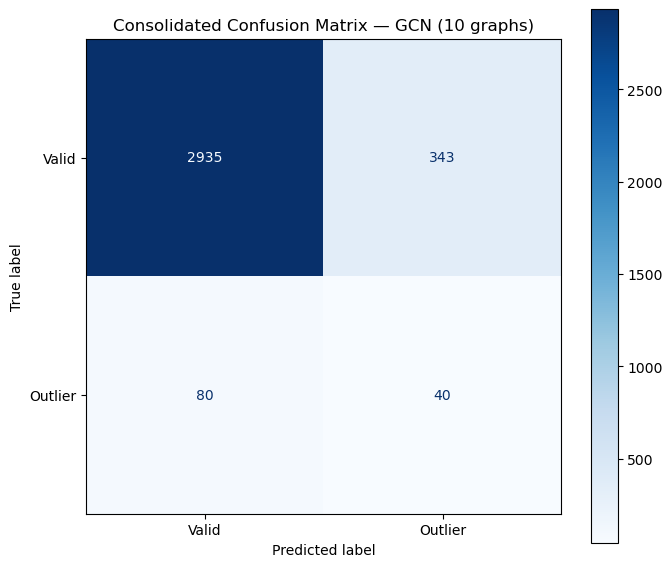


--- Generalization Test: SAGE ---


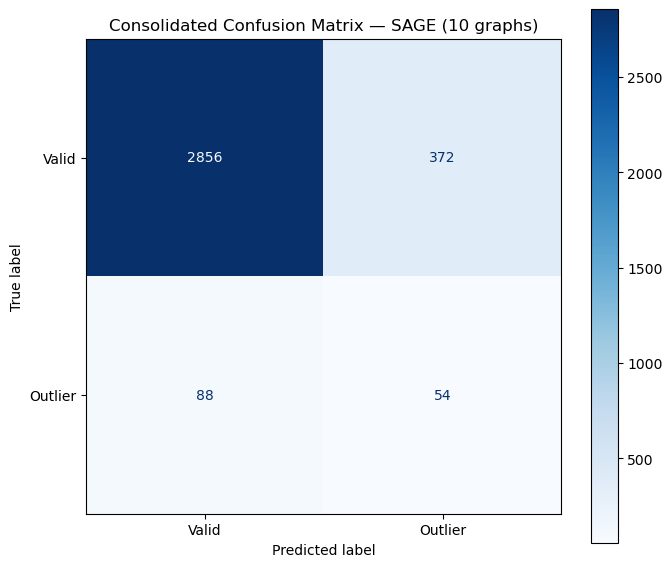


--- Generalization Test: RGCN ---


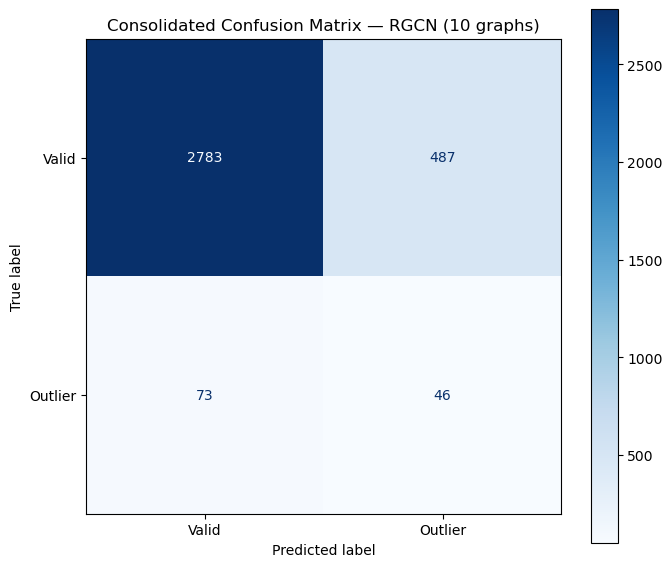

In [18]:
def test_gnn_consolidated(model, num_test_graphs=10,
                           req_size=50, func_size=50, comp_size=50):
    """
    Evaluate model on num_test_graphs freshly generated unseen graphs.
    Graph sizes default to match training — change here if you train on larger graphs.
    Returns dict with type1_acc and type2_acc for use in the combined comparison chart.
    """
    model.eval()

    all_y_true, all_y_pred = [], []
    type1_results = {'true': [], 'pred': []}
    type2_results = {'true': [], 'pred': []}

    for _ in range(num_test_graphs):
        g_test = generate_se_dataset_with_outliers_standard(
            req_size=req_size, req_depth=3,
            func_size=func_size, func_depth=4,
            comp_size=comp_size, comp_depth=4
        )
        data_test, _ = convert_to_pyg_data(g_test)

        with torch.no_grad():
            logits = model(data_test.x, data_test.edge_index, data_test.edge_attr)
            preds  = (torch.sigmoid(logits) > 0.5).float()

        all_y_true.append(data_test.y)
        all_y_pred.append(preds)

        is_alloc   = data_test.edge_attr[:, 1] == 1
        is_satisfy = data_test.edge_attr[:, 2] == 1

        type1_results['true'].append(data_test.y[is_alloc])
        type1_results['pred'].append(preds[is_alloc])
        type2_results['true'].append(data_test.y[is_satisfy])
        type2_results['pred'].append(preds[is_satisfy])

    y_true_final = torch.cat(all_y_true).cpu().numpy()
    y_pred_final = torch.cat(all_y_pred).cpu().numpy()

    t1_acc = (torch.cat(type1_results['true']).cpu().numpy() ==
              torch.cat(type1_results['pred']).cpu().numpy()).mean()
    t2_acc = (torch.cat(type2_results['true']).cpu().numpy() ==
              torch.cat(type2_results['pred']).cpu().numpy()).mean()

    # Per-model confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    cm = confusion_matrix(y_true_final, y_pred_final)
    ConfusionMatrixDisplay(cm, display_labels=['Valid', 'Outlier']).plot(ax=ax, cmap='Blues')
    ax.set_title(f"Consolidated Confusion Matrix — {model.gnn_type} ({num_test_graphs} graphs)")
    plt.tight_layout()
    plt.show()

    return {'model': model.gnn_type, 'type1_acc': t1_acc, 'type2_acc': t2_acc}


# Test all active models on unseen graphs
results = []
for name, model in models.items():
    print(f"\n--- Generalization Test: {name} ---")
    r = test_gnn_consolidated(model, num_test_graphs=10)
    results.append(r)

### Combined comparison chart

After all models are tested, plot Type 1 and Type 2 accuracy side by side for every active architecture. Y-axis starts at 0 so bar heights are honestly proportional.

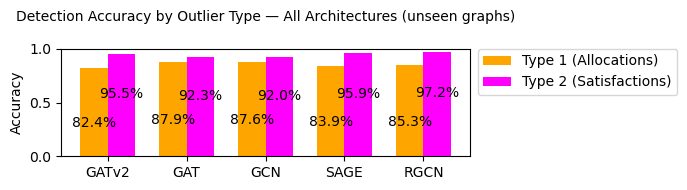

In [19]:
model_names      = [r['model'] for r in results]
type1_accuracies = [r['type1_acc'] for r in results]
type2_accuracies = [r['type2_acc'] for r in results]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 2))
rects1 = ax.bar(x - width/2, type1_accuracies, width,
                label='Type 1 (Allocations)', color='orange')
rects2 = ax.bar(x + width/2, type2_accuracies, width,
                label='Type 2 (Satisfactions)', color='magenta')
ax.set_ylabel('Accuracy', fontsize=10)

ax.set_title('Detection Accuracy by Outlier Type — All Architectures (unseen graphs)', 
             fontsize=10, pad=20)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1)   

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Iterate through the bar groups
for i, rects in enumerate((rects1, rects2)):
    # Flipped: Negative offset for Type 1 (orange), positive offset for Type 2 (magenta)
    y_offset = -8 if i == 0 else 8
    
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height / 2),
                    xytext=(0, y_offset), textcoords='offset points',
                    ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


## 9. Summary comparison

Prints a ranked summary table of generalization test accuracy across all active models. Re-run the cell above before this one to refresh `results`.

In [20]:
print(f"\n{'='*52}")
print(f"  Architecture Comparison — Unseen Graph Accuracy")
print(f"{'='*52}")
print(f"  {'Model':<10} {'Type 1 (Alloc)':>16} {'Type 2 (Satisfy)':>18}")
print(f"  {'-'*10} {'-'*16} {'-'*18}")

for r in sorted(results, key=lambda x: -(x['type1_acc'] + x['type2_acc'])):
    print(f"  {r['model']:<10} {r['type1_acc']:>15.2%} {r['type2_acc']:>17.2%}")

print(f"{'='*52}")
print()
print("Edge-aware models (GATv2, GAT, RGCN) have direct access to relation")
print("type during message passing. GCN and SAGE infer everything from node")
print("embeddings alone.")


  Architecture Comparison — Unseen Graph Accuracy
  Model        Type 1 (Alloc)   Type 2 (Satisfy)
  ---------- ---------------- ------------------
  RGCN                85.30%            97.19%
  GAT                 87.90%            92.26%
  SAGE                83.90%            95.92%
  GCN                 87.60%            91.97%
  GATv2               82.40%            95.49%

Edge-aware models (GATv2, GAT, RGCN) have direct access to relation
type during message passing. GCN and SAGE infer everything from node
embeddings alone.


scale=0.25x  pos_weight=4.2  F1=0.257  Recall=0.409  Precision=0.188  AUC=0.686
scale=0.50x  pos_weight=8.4  F1=0.204  Recall=0.227  Precision=0.185  AUC=0.628
scale=1.00x  pos_weight=16.8  F1=0.145  Recall=0.500  Precision=0.085  AUC=0.683
scale=2.00x  pos_weight=33.6  F1=0.250  Recall=0.545  Precision=0.162  AUC=0.742
scale=4.00x  pos_weight=67.3  F1=0.139  Recall=0.500  Precision=0.081  AUC=0.660
scale=8.00x  pos_weight=134.5  F1=0.129  Recall=0.955  Precision=0.069  AUC=0.685


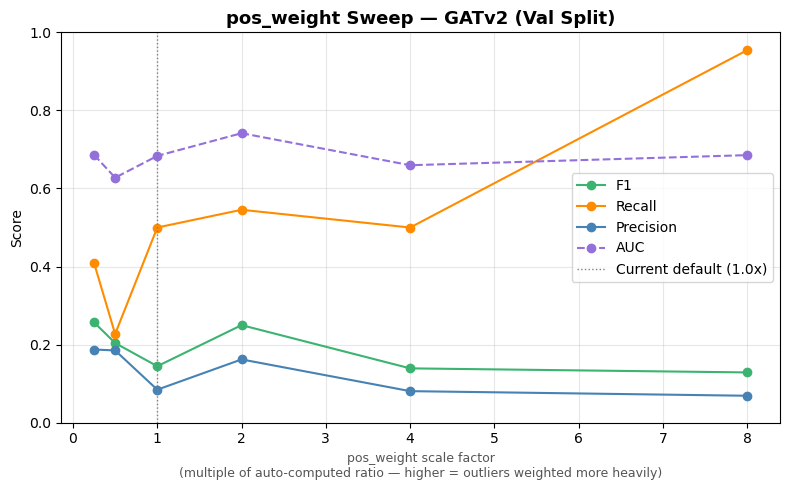


Best F1: 0.257 at scale=0.25x (pos_weight=4.2)
  Recall=0.409  Precision=0.188

To apply: set pos_weight = pos_weight * 0.25


In [33]:
from sklearn.metrics import f1_score, roc_auc_score

# ── pos_weight sweep ───────────────────────────────────────────
# Multiples of the auto-computed pos_weight to try.
# 1.0x = current default. Higher = model penalized more for missing outliers.
scale_factors = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]

# Run sweep on GATv2 only — apply winning value to all architectures after
sweep_model_name = 'GATv2'

sweep_results = []

for scale in scale_factors:
    scaled_pw = pos_weight * scale

    # Fresh model and optimizer for each run — don't carry over prior weights
    sweep_model = SEOutlierDetectorsweep_model = SEOutlierDetector(
        node_features=pyg_dataset.x.shape[1],
        edge_features=pyg_dataset.edge_attr.shape[1],
        hidden_channels=64,
        gnn_type=sweep_model_name
    )
    sweep_optimizer = torch.optim.Adam(sweep_model.parameters(), lr=0.01)
    sweep_criterion = torch.nn.BCEWithLogitsLoss(pos_weight=scaled_pw)

    # Train
    sweep_model.train()
    for epoch in range(1001):
        sweep_optimizer.zero_grad()
        out  = sweep_model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)
        loss = sweep_criterion(out[pyg_dataset.edge_train_mask],
                               pyg_dataset.y[pyg_dataset.edge_train_mask])
        loss.backward()
        sweep_optimizer.step()

    # Evaluate on val split
    sweep_model.eval()
    with torch.no_grad():
        logits = sweep_model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)
        probs  = torch.sigmoid(logits[pyg_dataset.edge_val_mask]).cpu().numpy()
        preds  = (probs > 0.5).astype(float)

    y_true = pyg_dataset.y[pyg_dataset.edge_val_mask].cpu().numpy()

    sweep_results.append({
        'scale':     scale,
        'pos_weight': scaled_pw.item(),
        'f1':        f1_score(     y_true, preds, pos_label=1, zero_division=0),
        'recall':    recall_score( y_true, preds, pos_label=1, zero_division=0),
        'precision': precision_score(y_true, preds, pos_label=1, zero_division=0),
        'auc':       roc_auc_score(y_true, probs),
    })
    print(f"scale={scale:.2f}x  pos_weight={scaled_pw:.1f}  "
          f"F1={sweep_results[-1]['f1']:.3f}  "
          f"Recall={sweep_results[-1]['recall']:.3f}  "
          f"Precision={sweep_results[-1]['precision']:.3f}  "
          f"AUC={sweep_results[-1]['auc']:.3f}")

# ── Plot results ───────────────────────────────────────────────
scales     = [r['scale']     for r in sweep_results]
f1s        = [r['f1']        for r in sweep_results]
recalls    = [r['recall']    for r in sweep_results]
precisions = [r['precision'] for r in sweep_results]
aucs       = [r['auc']       for r in sweep_results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scales, f1s,        marker='o', label='F1',        color='mediumseagreen')
ax.plot(scales, recalls,    marker='o', label='Recall',    color='darkorange')
ax.plot(scales, precisions, marker='o', label='Precision', color='steelblue')
ax.plot(scales, aucs,       marker='o', label='AUC',       color='mediumpurple',
        linestyle='--')

ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, label='Current default (1.0x)')
ax.set_xlabel('pos_weight scale factor\n'
              '(multiple of auto-computed ratio — higher = outliers weighted more heavily)',
              fontsize=9, color='#555555')
ax.set_ylabel('Score')
ax.set_title(f'pos_weight Sweep — {sweep_model_name} (Val Split)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Print best by F1 ──────────────────────────────────────────
best = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest F1: {best['f1']:.3f} at scale={best['scale']}x "
      f"(pos_weight={best['pos_weight']:.1f})")
print(f"  Recall={best['recall']:.3f}  Precision={best['precision']:.3f}")
print(f"\nTo apply: set pos_weight = pos_weight * {best['scale']}")